In [1]:
import numpy as np
import jax
from jax import Array, lax
import jax.numpy as jnp
import jax.random as jrnd
import sympy as sp
from jax.scipy.special import xlogy
from numpy.linalg import matrix_power

import os, sys, pathlib
os.environ["OPENBLAS_NUM_THREADS"] = "1"
_project_root = pathlib.Path.cwd().resolve()
sys.path.insert(0, str(_project_root.parents[0]))
sys.path.insert(0, str(_project_root.parents[1]))
jax.config.update('jax_enable_x64', 'false')

from physics.markov import matrix_powers, H, KL, get_q_star, bound, bound2, mmc, get_traj, pop, pmmc2
from physics.glauber import dense_generator_from_rates, heat_rate_vectors
from src.categorization import show_latex_bmatrix
import src.symmetry.permutations as perms
from src.symmetry.permutations import perm_from_cycles, perm_hom, generated_group

In [2]:
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.axes import Axes
from IPython.display import display, Math, Markdown

mpl.rcParams.update({
  "font.size": 16,
  "axes.titlesize": 20,
  "axes.labelsize": 16,
  "xtick.labelsize": 9,
  "ytick.labelsize": 9,
  "figure.dpi": 150,
  "savefig.dpi": 300,
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "mathtext.fontset": "dejavusans",
  "text.usetex": True,
  "font.family": "Helvetica",
})


In [ ]:
# Probability of reading a 0
p = 0.1
q = 1 - p
# 20-state DFA
n = 20
G20 = np.zeros((n, n))

# States:
# 0-4   : A1-A5
# 5-9   : B1-B5
# 10-14 : C1-C5
# 15-19 : D1-D5

for i in range(5):
    nxt = (i + 1) % 5

    # ---------- A ----------
    G20[nxt, i] += p            # A_i --0--> A_{i+1}
    G20[5+nxt, i] += q          # A_i --1--> B_{i+1}

    # ---------- B ----------
    G20[10+nxt, 5+i] += p       # B_i --0--> C_{i+1}
    G20[5+nxt, 5+i] += q        # B_i --1--> B_{i+1}

    # ---------- C ----------
    G20[nxt, 10+i] += p         # C_i --0--> A_{i+1}
    G20[15+nxt, 10+i] += q      # C_i --1--> D_{i+1}
    # ---------- D ----------
    G20[15+nxt, 15+i] += 1      # D_i -----> D_{i+1}
    
print(G20)
# Minimal 4-state DFA

G4 = np.array([
    [p,   0,   p,   0],
    [q,   q,   0,   0],
    [0,   p,   0,   0],
    [0,   0,   q,   1]
], dtype=float)

Ns=np.arange(1,50)

p0 = np.concatenate((np.array([1]), np.zeros(19)))
G20_mmc = np.array([pmmc2(p0, G20, N) for N in Ns])

p0=np.array([1,0,0,0])
G4_mmc = np.array([pmmc2(p0, G4, N) for N in Ns])


In [ ]:
num = 27
print(f"{num:b}")

In [ ]:
g23 = perms.from_cycles(((2,3),), degree=3)
g12 = perms.from_cycles(((1,2),), degree=3)
C3 = generated_group((g23, g12))
print(C3.matrices())

In [ ]:
# 00011 -> 3
# 00110 -> 6
# 01001 -> 9
# 01100 -> 12
# 01111 -> 15
# 10010 -> 18
# 10101 -> 21
# 11000 -> 24
# 11011 -> 27

In [3]:


def make_div3_ops():
  g23 = perms.from_cycles(((2,3),), degree=3)
  g12 = perms.from_cycles(((1,2),), degree=3)
  P0 = perms.perm_hom(g23)
  P1 = perms.perm_hom(g12)
  return P0, P1

def make_div3_memory_G(m, p):
  # m = number of redundant remembered bits
  # m = 0 gives the minimal 3-state DFA
  m = int(m)
  nh = 2 ** m
  n = 3 * nh
  P0, P1 = make_div3_ops()

  if m == 0:
    return p * P0 + (1 - p) * P1

  # def idx(r, h):
  #   return r * nh + h

  # all bits below m-1 bit
  mask = 2 ** (m - 1) - 1

  G_h0, G_h1 = jnp.zeros((nh, nh)), jnp.zeros((nh, nh))
  for h in range(nh):
    tail = h & mask
    # New histories
    h0 = (tail << 1) | 0
    h1 = (tail << 1) | 1
    G_h0 = G_h0.at[h0, h].add(1)
    G_h1 = G_h1.at[h1, h].add(1)

  # OLD
  # for r in range(3):
  #   # New remainders
  #   r0 = (2 * r) % 3
  #   r1 = (2 * r + 1) % 3
  #   P0 = P0.at[r0, r].add(1)
  #   P1 = P1.at[r1, r].add(1)

  G0 = jnp.kron(P0, G_h0)
  G1 = jnp.kron(P1, G_h1)
  # print(G_h0)
  # print(G_h1)
  return p * G0 + (1-p) * G1

def cyclic_loop(L):
  # for a in range(L):
    # R = R.at[(a + 1) % L, a].set(1.0)
  perm = perms.from_cycles((tuple(range(1, L+1)),))
  return perms.perm_hom(perm)


def make_div3_loop_G(L, p):
  P0, P1 = make_div3_ops()
  G_min = p * P0 + (1 - p) * P1
  R = cyclic_loop(L)
  return jnp.kron(G_min, R)

def make_div3_aper_G(L, p):
  P0, P1 = make_div3_ops()
  I = jnp.eye(L)
  R = cyclic_loop(L)
  G0 = p * jnp.kron(P0, I)
  G1 = (1 - p) * jnp.kron(P1, R)
  return G0 + G1

def make_mathieu10_G(p):
  P0, P1 = make_div3_ops()
  sigma = perms.from_cycles((tuple(range(1, 12)),))
  
  tau = perms.from_cycles(((3,7,11,8),(4,10,5,6)), degree=11)
  G0 = jnp.kron(P0, perms.perm_hom(sigma))
  G1 = jnp.kron(P1, perms.perm_hom(tau))
  return p * G0 + (1-p) * G1

def make_mathieu10_G2(p):
  P0, P1 = make_div3_ops()
  sigma = perms.from_cycles((tuple(range(1, 12)),))
  
  tau = perms.from_cycles(((3,7,11,8),(4,10,5,6)), degree=11)
  G0 = jnp.kron(P0, perms.perm_hom(sigma))
  G1 = jnp.kron(P1, jnp.eye(11))
  return p * G0 + (1-p) * G1

def make_mathieu10_G3(p):
  P0, P1 = make_div3_ops()
  sigma = perms.from_cycles((tuple(range(1, 12)),))
  
  tau = perms.from_cycles(((3,7,11,8),(4,10,5,6)), degree=11)
  G0 = jnp.kron(P0, jnp.eye(11))
  G1 = jnp.kron(P1, perms.perm_hom(tau))
  return p * G0 + (1-p) * G1


def make_something(p, n0=2, n1=1, n2=1):
  N = sum((n0, n1, n2))
  P0, P1 = make_div3_ops()
  G0 = jnp.zeros((N, N)).at[1:, 1:].set(P0)
  G1 = jnp.zeros((N, N)).at[1:, 1:].set(P1)

  flop = jnp.array([[0.0, 1.0], [1.0, 0.0]])
  stay = jnp.eye(2)
  G0 = G0.at[:2, :2].set(flop)

  g12_34 = perms.from_cycles(((1, 2), (3,4),), degree=4)
  G0 = perms.perm_hom(g12_34)
  print(G0) 

  # print(G0.reshape(2,4,2, order='F').reshape(4,4, order='F'))

  G1 = G1.at[2, 0].set(1)
  G1 = G1.at[1, 2].set(0)
  G1 = G1.at[0, 2].set(1)
  # print(G1.reshape(2,4, 2))

  # pi = jnp.eye(3, 4, k=1)
  # print(pi)
  # pi2 = G0[1:]
  # print(pi2)
  # pi2 = jnp.array([
  #   [1.0, 0.0, 0.0],
  #   [0.0, 0.0, 0.0],
  #   [0.0, 1.0, 0.0],
  #   [0.0, 0.0, 1.0],
  # ])
  # print(pi2.T)
  # print(pi @ G0 @pi2)

In [ ]:
print(make_something(1.0))
# [0a, 0b, 1, 2]

In [ ]:
from functools import partial
@partial(jax.jit, static_argnames=("N_max",))
def get_traj(G, p0, N_max):
  # p <- G @ p
  def traj(p, x):
    return G @ p, p # one mat-vec per step, not mat-mat
  pN, pts = lax.scan(traj, init=p0, length=N_max)
  return pN, jnp.concatenate((pts, pN[None]))

def get_stuff(G: Array, p0: Array, N_max):
  pN, pts = get_traj(G, p0, N_max)
  p_avgs = jnp.cumsum(pts[:-1], axis=0) / Ns[:, None]
  Gp_avgs = p_avgs @ G.T
  landauer = - H(pts[1:], axis=1) + H(p0)
  pmmcs = - landauer + Ns * (H(p_avgs, axis=1) - H(Gp_avgs, axis=1))
  vals, vecs = np.linalg.eig(G)
  idx = np.argmin(np.abs(vals - 1.0))
  pi  = np.real(vecs[:, idx])
  pi  = np.clip(pi / pi.sum(), 0, None)
  kl = KL(p0, pi)
  return pts, pmmcs, pi, kl

Two DFAs are isomorphic if there exists a bijective mapping $\varphi: R\to R'$ such that 
- $\varphi(x_0)=x_0'$, i.e., the initial state is preserved, 
- $x\in A$ if and only if $\varphi(x)\in F'$ for each $x\in R$, 
- and $y\in\delta(x, a)$ if, and only if, $\varphi(y)\in\delta'(\varphi(x), a)$, for each $x,y\in R$ and $a\in\Sigma$.

NOTE:
- the asymptotic MMC should be exactly $\log N$, where $N$ is the size of the accessible component of the initial distribution


I would expect the behavior to become qualitatively different.

In particular, for 0<p<1, that 12-state component should mix to its uniform distribution, so from a delta initial state you should obtain asymptotically something corresponding to

D(δ∥u
12
	​

)=log12,

rather than

D(δ∥u
3
	​

)=log3.

That would be a clean demonstration that it is the orbit of the auxiliary group action containing the initial state, not the nominal DFA dimension, that matters.

In [ ]:
N_max = 10_000
Ns = jnp.arange(1, N_max + 1)
ps = jnp.linspace(0, 1, 10, endpoint=False)[1:]

norm = mcolors.Normalize(vmin=ps.min(), vmax=ps.max())
cmap = mpl.colormaps["viridis"]
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)


labels = (
  r"$P_0\otimes \sigma + P_1\otimes \tau$", 
  r"$P_0\otimes \sigma + P_1\otimes I$", 
  r"$P_0\otimes I + P_1\otimes \tau$")
fig, _axs = plt.subplots(1, 3, figsize=(9, 3), dpi=300, squeeze=False, sharey=True)
axs: list[Axes] = _axs.flatten().tolist()
p0_M = jnp.zeros((3 * 11,)).at[0].set(1)
for i, p in enumerate(ps):
  color = cmap(norm(p))
  p0_min = jnp.zeros((3,)).at[0].set(1)
  G_min = make_div3_memory_G(0, p)
  pts, pmmcs_min, pi_min, kl_min = get_stuff(G_min, p0_min, N_max)
  for j, (f, label) in enumerate(zip((make_mathieu10_G, make_mathieu10_G2, make_mathieu10_G3), labels)):
    
    axs[j].plot(Ns, pmmcs_min, c=color, alpha=0.5)
    axs[j].hlines(
      y=kl_min, xmin=Ns[0], xmax=Ns[-1],
      color=color, linestyles='dotted', lw=1.5,
      label=r'$\mathrm{D}(p_{0,min} \| \pi_{min})$'
    )
    axs[j].set(title=label)

    G_M = f(p)
    print(f"mathieu loop: {np.linalg.det(G_M)}")
    pts, pmmcs_M, pi_M, kl_M = get_stuff(G_M, p0_M, N_max)
    print(jnp.max(jnp.abs(pi_M - jnp.sum(pts[:-1], axis=0)/N_max)))
    print(KL(p0_M, jnp.sum(pts[:-1], axis=0)/N_max))
    axs[j].plot(Ns, pmmcs_M, c=color, alpha=0.5)
    axs[j].hlines(
      y=KL(p0_M, jnp.sum(pts[:-1], axis=0)/N_max), xmin=Ns[0], xmax=Ns[-1],
      color=color, linestyles='dotted', lw=1.5,
      label=r'$\mathrm{D}(p_{0,min} \| \pi_{min})$'
    )
    axs[j].set(xscale='log')
    print()
plt.show()

In [ ]:
N_max = 10_000
Ns = jnp.arange(1, N_max + 1)
tau = 0.1
beta = 1.0
Delta = 4.0
# fig, _axs = plt.subplots(9, 1, figsize=(3, 20), dpi=300, squeeze=False)
# axs: list[Axes] = _axs.flatten().tolist()
ps = jnp.linspace(0, 1, 10, endpoint=False)[1:]

norm = mcolors.Normalize(vmin=ps.min(), vmax=ps.max())
cmap = mpl.colormaps["viridis"]
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

# big_fig, big_ax = plt.subplots(figsize=(3, 3), dpi=300)
# fig, ax = plt.subplots(figsize=(3, 3), dpi=300, squeeze=True)
for i, p in enumerate(ps):
  color = cmap(norm(p))
  # print(p, -jnp.log(1-p))
  fig, _axs = plt.subplots(1, 3, figsize=(9, 3), dpi=300, squeeze=False, sharey=True)
  axs: list[Axes] = _axs.flatten().tolist()

  # kl_old = 0
  for m, L in enumerate(range(1, 4)):
    p0_m = jnp.zeros((3*2**m)).at[0].set(1)
    G_m = make_div3_memory_G(m, p)
    print(f"memory: {np.linalg.det(G_m)}")

    pts, pmmcs, pi_m, kl_m = get_stuff(G_m, p0_m, N_max)
    q_bar = jnp.sum(pts[:-1], axis=0)/N_max
    print(pi_m, q_bar)
    axs[0].plot(Ns, pmmcs, c='black', alpha=0.5, label=fr"$m={m}$")
    axs[0].hlines(
      y=kl_m, xmin=Ns[0], xmax=Ns[-1],
      color='black', linestyles='dotted', lw=1.5,
      label=r'$\mathrm{D}(p_{0,min} \| \pi_{min})$'
    )
    axs[0].hlines(
      y=KL(p0_m, q_bar), xmin=Ns[0], xmax=Ns[-1],
      color='red', linestyles='dotted', lw=1.5,
      label=r'$\mathrm{D}(p_{0,min} \| \pi_{min})$'
    )

    p0_L = jnp.zeros((3*L)).at[0].set(1)
    G_L = make_div3_loop_G(L, p)
    print(f"loop: {np.linalg.det(G_L)}")

    # print((G_m > 0).astype(jnp.int32))
    # print((G_m.T @ G_m > 0).astype(jnp.int32))
    pts, pmmcs, pi_L, kl_L = get_stuff(G_L, p0_L, N_max)
    q_bar = jnp.sum(pts[:-1], axis=0)/N_max
    print(pi_L, q_bar)
    axs[1].plot(Ns, pmmcs, c='black', alpha=0.5, label=fr"$L={L}$")
    axs[1].hlines(
      y=kl_L, xmin=Ns[0], xmax=Ns[-1],
      color='black', linestyles='dotted', lw=1.5,
      label=r'$\mathrm{D}(p_{0,min} \| \pi_{min})$'
    )
    axs[1].hlines(
      y=KL(p0_L, q_bar), xmin=Ns[0], xmax=Ns[-1],
      color='red', linestyles='dotted', lw=1.5,
      label=r'$\mathrm{D}(p_{0,min} \| \pi_{min})$'
    )


    p0_a = jnp.zeros((3*L)).at[0].set(1)
    G_a = make_div3_aper_G(L, p)
    print(f"aperiodic loop: {np.linalg.det(G_a)}")
    pts, pmmcs, pi_a, kl_a = get_stuff(G_a, p0_a, N_max)
    q_bar = jnp.sum(pts[:-1], axis=0)/N_max
    print(pi_a, q_bar)
    axs[2].plot(Ns, pmmcs, c='black', alpha=0.5, label=fr"$L={L}$")
    axs[2].hlines(
      y=kl_a, xmin=Ns[0], xmax=Ns[-1],
      color='black', linestyles='dotted', lw=1.5,
      label=r'$\mathrm{D}(p_{0,min} \| \pi_{min})$'
    )
    axs[2].hlines(
      y=KL(p0_a, q_bar), xmin=Ns[0], xmax=Ns[-1],
      color='red', linestyles='dotted', lw=1.5,
      label=r'$\mathrm{D}(p_{0,min} \| \pi_{min})$'
    )

  print()
  axs[0].set(xlabel=r"$N$", ylabel=r"$\mathcal{MC}_N(\bar{q})$", title="Memory", xscale='log')
  axs[1].set(xlabel=r"$N$", xscale='log', title="loop")
  axs[2].set(xlabel=r"$N$", xscale='log', title="loop conditional")
  fig.suptitle(fr"$p={p:.2f}$")
  plt.show()



In [ ]:
import sympy as sp
from IPython.display import display

def make_div3_memory_G_sympy(m, p, q):
    nh = 1 if m == 0 else 2**m
    n = 3 if m == 0 else 3 * nh
    G = sp.MutableDenseMatrix.zeros(n, n)

    def idx(r, h=0):
        return r if m == 0 else r * nh + h

    mask = 0 if m == 0 else 2**(m - 1) - 1

    for r in range(3):
      for h in range(nh):
        source = idx(r, h)
        tail = h & mask
        h0 = 0 if m == 0 else (tail << 1)
        h1 = 0 if m == 0 else ((tail << 1) | 1)

        r0 = (2 * r) % 3
        r1 = (2 * r + 1) % 3

        G[idx(r0, h0), source] += q
        G[idx(r1, h1), source] += p

    return sp.Matrix(G)

def cyclic_loop_sympy(L):
    R = sp.zeros(L, L)
    for a in range(L):
        R[(a + 1) % L, a] = 1
    return R

def make_div3_G_sympy(p, q):
    G = sp.zeros(3, 3)
    for r in range(3):
        r0 = (2 * r) % 3
        r1 = (2 * r + 1) % 3
        G[r0, r] += q
        G[r1, r] += p
    return G

def make_div3_loop_G_sympy(L, p, q):
    G_min = make_div3_G_sympy(p, q)
    R = cyclic_loop_sympy(L)
    return sp.kronecker_product(G_min, R)

import sympy as sp
N_max = 10_000
Ns = jnp.arange(1, N_max + 1)
tau = 0.1
beta = 1.0
Delta = 4.0

p = sp.Symbol('p')
q = sp.Symbol('q')

for m, L in enumerate(range(1, 4)):
  G_m = make_div3_memory_G_sympy(m, p, q)
  display(G_m)
  G_L = make_div3_loop_G_sympy(L, p, q)
  print(f"L = {L}")
  display(G_L)

In [6]:
SIMPLEX_VERTICES = np.array([
  [0.0, 0.0],
  [1.0, 0.0],
  [0.5, np.sqrt(3.0) / 2.0],
])

def simplex_to_cartesian(points):
  return np.asarray(points) @ SIMPLEX_VERTICES

def sample_simplex(levels=45):
  points = []
  for i in range(levels + 1):
    for j in range(levels + 1 - i):
      k = levels - i - j
      points.append((i / levels, j / levels, k / levels))
  return jnp.array(points, dtype=jnp.float32)

def regularize_simplex(points, eps=1e-3):
  # Keep KL terms finite near the simplex boundary without changing the plot mesh.
  points = jnp.clip(points, eps, None)
  return points / jnp.sum(points, axis=-1, keepdims=True)

def format_prob(point):
  return r"\left(" + r",\,".join(f"{x:.2f}" for x in np.asarray(point)) + r"\right)"

def normalize_simplex_point(point):
  point = np.asarray(point)
  return point / point.sum()

def draw_simplex_frame(ax: Axes, color="0.25", lw=1.0):
  verts = SIMPLEX_VERTICES[[0, 1, 2, 0]]
  ax.plot(verts[:, 0], verts[:, 1], color=color, lw=lw, zorder=2)

def add_corner_labels(ax: Axes, fontsize=9, color="0.2"):
  # Place the shared barycentric key just inside panel a.
  ax.text(SIMPLEX_VERTICES[0,0] + 0.035, SIMPLEX_VERTICES[0,1] + 0.025,
          r"$(1,0,0)$", ha="left", va="bottom", fontsize=fontsize, color=color)
  ax.text(SIMPLEX_VERTICES[1,0] - 0.035, SIMPLEX_VERTICES[1,1] + 0.025,
          r"$(0,1,0)$", ha="right", va="bottom", fontsize=fontsize, color=color)
  ax.text(SIMPLEX_VERTICES[2,0], SIMPLEX_VERTICES[2,1] - 0.035,
          r"$(0,0,1)$", ha="center", va="top", fontsize=fontsize, color=color)



In [7]:
# get minimal
p = 0.1
G = make_div3_memory_G(0, p)
p0 = jnp.zeros((3,)).at[0].set(1)

# ---- data
n_values = (1, 10, 100, 1000)
N_max = max(n_values)
Ns = jnp.arange(1, N_max + 1)
grid = sample_simplex(levels=60)
grid_eval = regularize_simplex(grid)
grid_xy = simplex_to_cartesian(grid)
triang = mtri.Triangulation(grid_xy[:, 0], grid_xy[:, 1])

pN, pts = get_traj(G, p0, N_max)

evaluator = jax.jit(jax.vmap(lambda q: KL(pts[:-1], q, axis=1) - KL(pts[1:], G @ q, axis=1)))
mmmcs = evaluator(grid_eval)
print(mmmcs.shape)
p_avgs = jnp.cumsum(pts[:-1], axis=0) / Ns[:, None]


mmc_by_n = {}
q_star_by_n = {}
for n in n_values:
  mmc_by_n[n] = np.asarray(jnp.sum(mmmcs[:, :n], axis=1))
  q_star_by_n[n] = np.asarray(p_avgs[n-1])

traj_xy = simplex_to_cartesian(p_avgs)


vmin=min(values.min() for values in mmc_by_n.values())
vmax=max(values.max() for values in mmc_by_n.values())


print(min(values.min() for values in mmc_by_n.values()))

# Choose "linear" for an unlogged colorbar or "symlog" for the previous scale.
color_scale = "symlog"
if color_scale == "linear":
  norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
elif color_scale == "symlog":
  norm = mcolors.SymLogNorm(linthresh=1e-2, vmin=vmin, vmax=vmax)
else:
  raise ValueError(f"Unsupported color_scale: {color_scale!r}")

(1891, 1000)
0.0009959686717944103


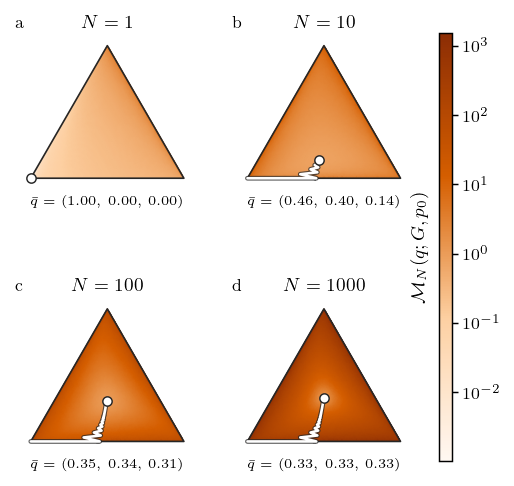

In [8]:
# ---- publication figure
import matplotlib.patheffects as pe

SIMPLEX_PAPER_RC_PARAMS = {
  "font.family": "serif",
  "mathtext.fontset": "cm",
  "font.size": 9,
  "axes.titlesize": 9,
  "axes.labelsize": 9,
  "xtick.labelsize": 8,
  "ytick.labelsize": 8,
  "axes.linewidth": 0.7,
  "text.usetex": True,
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "svg.fonttype": "none",
}
mpl.rcParams.update(SIMPLEX_PAPER_RC_PARAMS)

C_MC = "#D55E00"
mmc_cmap = mcolors.LinearSegmentedColormap.from_list(
  "mmc_seq", ["#FFF8F2", "#FDD0A2", C_MC, "#8C2D04"]
)
mmc_cmap.set_bad("#BDBDBD")

MM_PER_INCH = 25.4
fig = plt.figure(figsize=(89 / MM_PER_INCH, 92 / MM_PER_INCH))
gs = fig.add_gridspec(
  2, 2, left=0.08, right=0.83, top=0.95, bottom=0.055, wspace=0.22, hspace=0.18
)
axs = [fig.add_subplot(gs[i // 2, i % 2]) for i in range(len(n_values))]
panel_labels = "abcd"

mappable = None
for i, (ax, n) in enumerate(zip(axs, n_values)):
  q_star = q_star_by_n[n]
  q_star_xy = simplex_to_cartesian(normalize_simplex_point(q_star))
  mappable = ax.tripcolor(
    triang,
    mmc_by_n[n],
    shading="gouraud",
    cmap=mmc_cmap,
    norm=norm,
    rasterized=True,
  )
  draw_simplex_frame(ax, color="0.15", lw=0.8)

  # A dark halo keeps the white trajectory legible across the full color scale.
  trajectory, = ax.plot(
    traj_xy[:n, 0],
    traj_xy[:n, 1],
    color="white",
    lw=1.25,
    solid_capstyle="round",
    solid_joinstyle="round",
    zorder=3,
  )
  trajectory.set_path_effects([
    pe.Stroke(linewidth=2.3, foreground="0.15", alpha=0.75),
    pe.Normal(),
  ])
  ax.scatter(
    q_star_xy[0],
    q_star_xy[1],
    facecolor="white",
    edgecolor="0.15",
    linewidth=0.7,
    s=20,
    zorder=4,
  )

  ax.text(
    0.5,
    -0.105,
    rf"$\bar q={format_prob(q_star)}$",
    ha="center",
    va="top",
    fontsize=6.5,
  )
  ax.text(
    -0.02,
    1.02,
    panel_labels[i],
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=8,
    fontweight="bold",
    clip_on=False,
  )
  ax.set_title(rf"$N={n}$", pad=3)
  ax.set(
    aspect="equal",
    xlim=(-0.08, 1.08),
    ylim=(-0.13, SIMPLEX_VERTICES[2, 1] + 0.08),
  )
  ax.axis("off")

# Label the barycentric convention once; it is shared by every panel.
# add_corner_labels(axs[0], fontsize=6.5, color="0.15")

fig.canvas.draw()
top_box = axs[1].get_position()
bottom_box = axs[2].get_position()
cax = fig.add_axes([0.88, bottom_box.y0, 0.025, top_box.y1 - bottom_box.y0])
cb = fig.colorbar(mappable, cax=cax)
cb.set_label(r"$\mathcal{M}_N(q;G,p_0)$", rotation=90, labelpad=5)
cb.ax.yaxis.set_label_position("left")
cb.ax.tick_params(which="major", direction="out", length=3, width=0.7, pad=2)
cb.ax.tick_params(which="minor", direction="out", length=1.8, width=0.6)
cb.outline.set_linewidth(0.7)

plt.show()

In [9]:
output_dir = pathlib.Path("media")
output_dir.mkdir(parents=True, exist_ok=True)
output_stem = output_dir / "simplex_heatmap_div3_p09"

fig.savefig(
  output_stem.with_suffix(".pdf"),
  dpi=600,
  facecolor="white",
  metadata={"Title": "Simplex trajectory heatmap", "Creator": "Matplotlib"},
)
fig.savefig(
  output_stem.with_suffix(".svg"),
  dpi=600,
  facecolor="white",
  metadata={"Title": "Simplex trajectory heatmap"},
)
fig.savefig(
  output_stem.with_suffix(".png"),
  dpi=600,
  facecolor="white",
  metadata={"Title": "Simplex trajectory heatmap"},
)

In [ ]:
ah